## Script for the first statistics of the regression run

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
#setting filepaths the datasets

pi_results_filepath = "../output/PI_DataSe_regression_results.csv"
#INI_results_filepath = "./INI_DataSe_results.csv"  INI did not have any results as the threshold are not set by


nnrti_results_filepath = "../output/NNRTI_DataSe_regression_results.csv"


nrti_results_filepath = "../output/NRTI_DataSe_regression_results.csv"

ini_results_filepath = "../output/INI_DataSe_regression_results.csv"

#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]

pi_results_filepath_st = "../output/PI_DataSe_Standard_comparison_results.csv"

nnrti_results_filepath_st = "../output/NNRTI_DataSe_Standard_comparison_results.csv"

nrti_results_filepath_st = "../output/NRTI_DataSe_Standard_comparison_results.csv"

ini_results_filepath_st = "../output/INI_DataSe_Standard_comparison_results.csv"



#creating lists with filepaths for later visualisation
filepath_list_st = [pi_results_filepath_st, nnrti_results_filepath_st, nrti_results_filepath_st, ini_results_filepath_st]


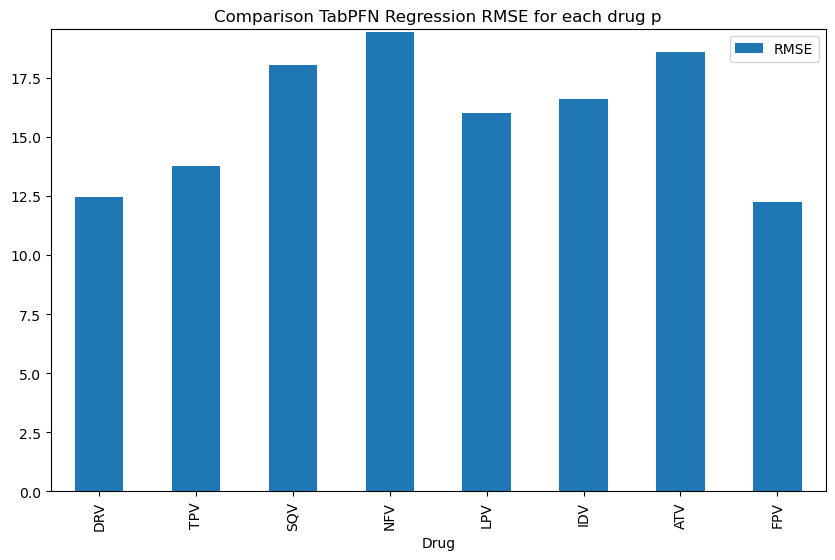

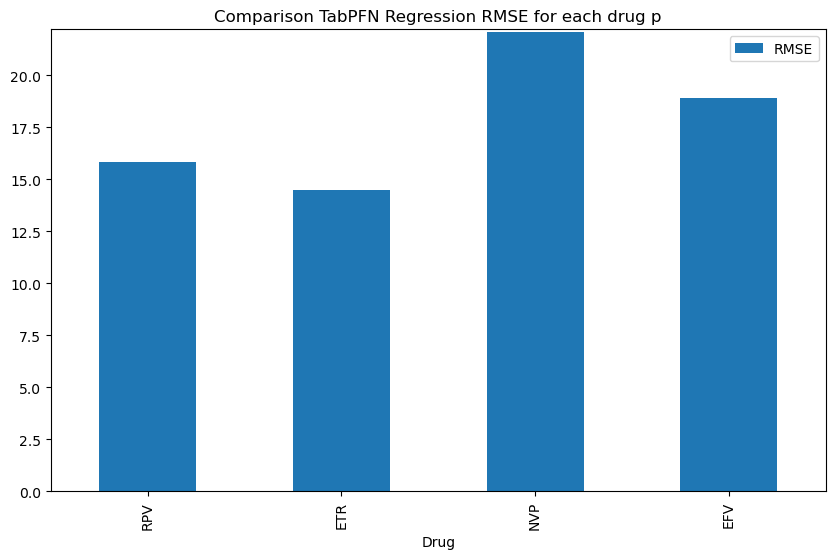

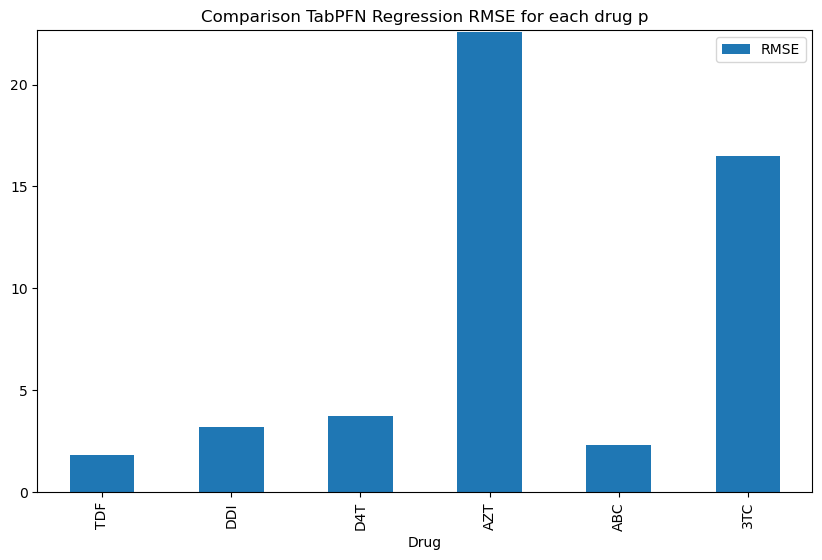

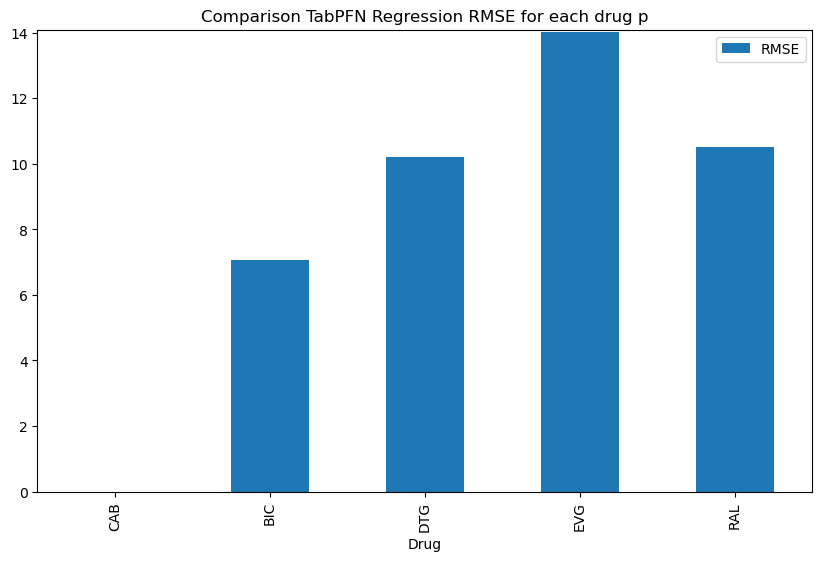

In [3]:
for filepath in filepath_list:
    target = pd.read_csv(filepath)
    ax = target.plot.bar(x='Drug', y='RMSE', figsize=(10, 6))
    ax.set_ylim(0.0, target['RMSE'].max() * 1.005)
    ax.set_title('Comparison TabPFN Regression RMSE for each drug ' + filepath.split("/")[1].strip("_DataSe_regression_results.csv"))

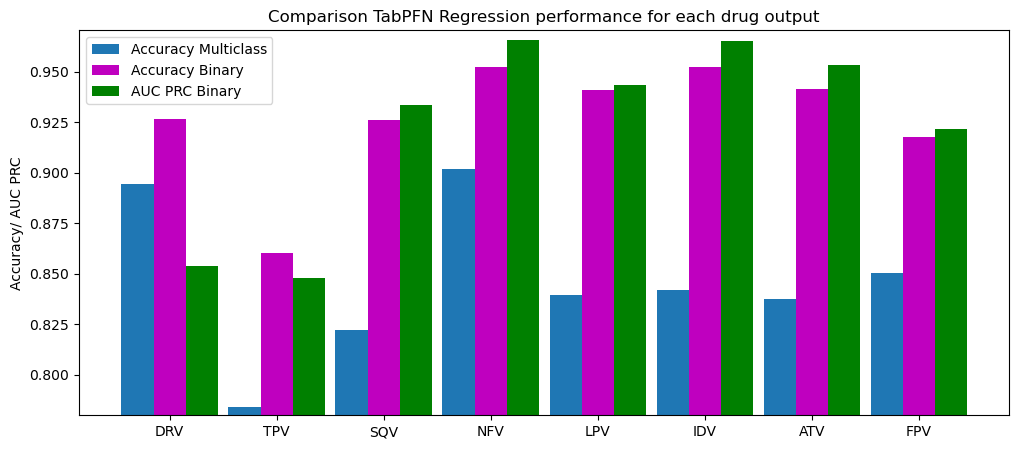

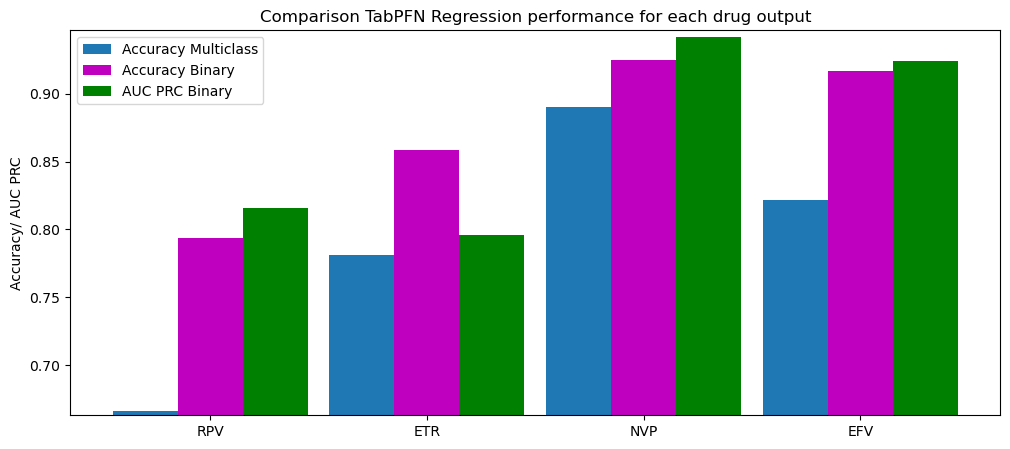

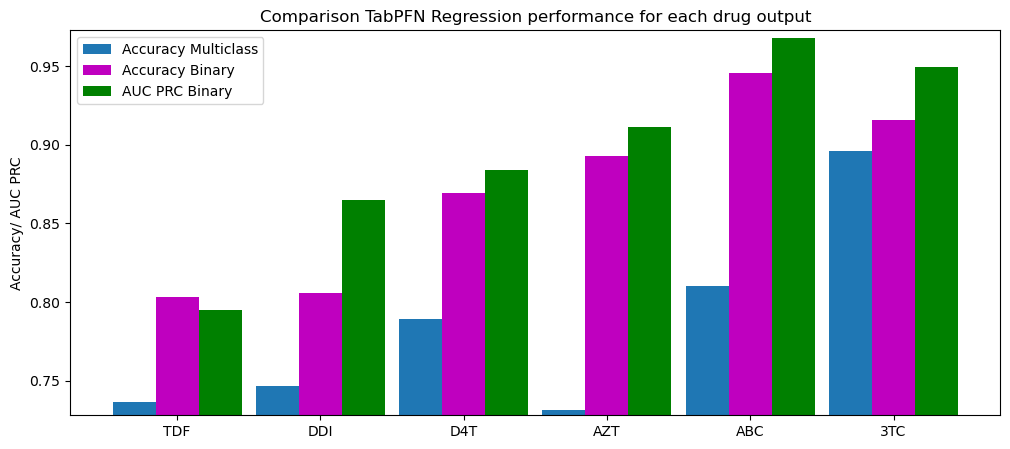

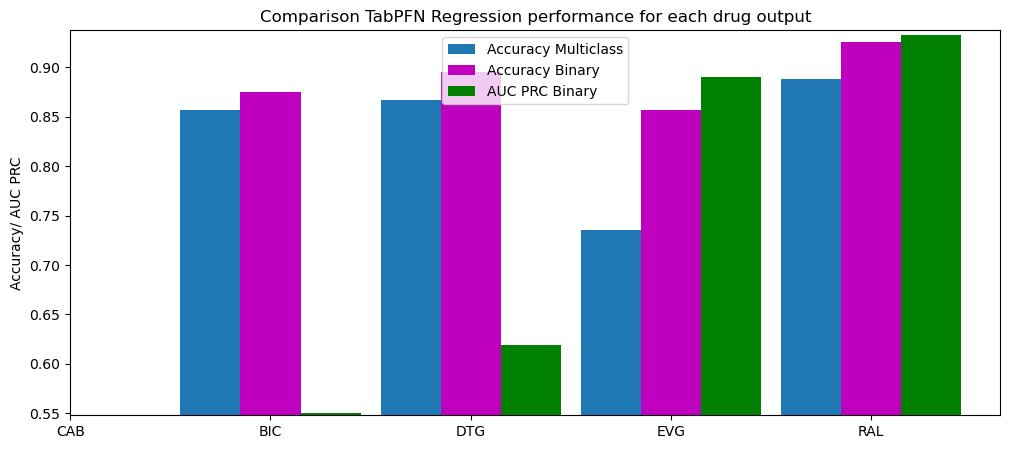

In [5]:


for filepath in filepath_list:
    target = pd.read_csv(filepath)


    fig, ax = plt.subplots(1, figsize=(12, 5))

    #fig.suptitle('Horizontally stacked subplots')

    w, x = 0.3, np.arange(len(target["Drug"]))

    ax.bar(x - w, target["AUC ROC MC"], width=w, label='Accuracy Multiclass')
    ax.bar(x      , target["AUC ROC BI"], width=w, color="m", label='Accuracy Binary')
    ax.bar(x + w, target["AUC PRC BI"], width=w, color="g", label='AUC PRC Binary')

    ax.set_xticks(x)
    ax.set_xticklabels(target["Drug"])
    ax.set_ylabel('Accuracy/ AUC PRC')
    ax.set_ylim(min(target['AUC ROC MC'].min(), target['AUC ROC BI'].min(), target['AUC PRC BI'].min())* 0.995, min(1.0, max(target['AUC ROC MC'].max(), target['AUC ROC BI'].max(), target['AUC PRC BI'].max())  * 1.005))
    ax.set_title('Comparison TabPFN Regression performance for each drug ' + filepath.split("/")[1].split("_")[0])
    ax.legend()



    plt.savefig("../figures/" + filepath.split("/")[1].split("_")[0] + "_Regression_performance.png")


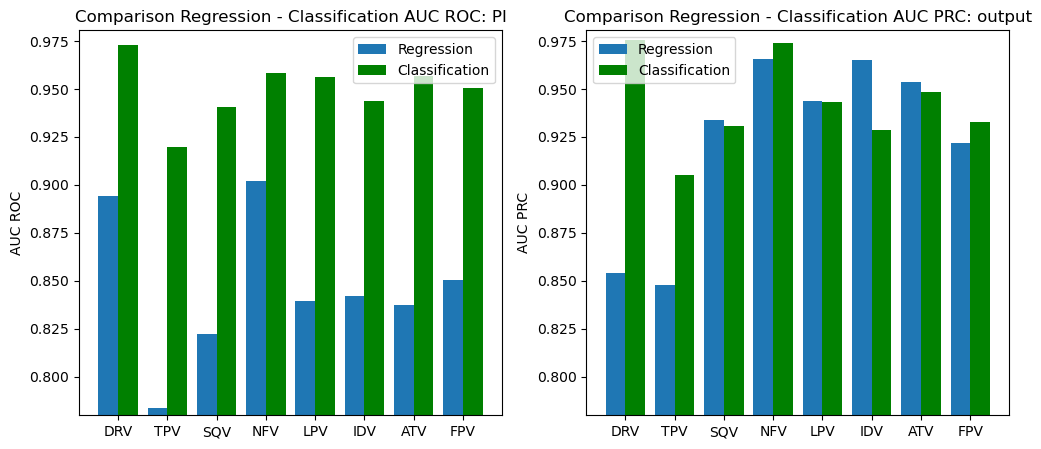

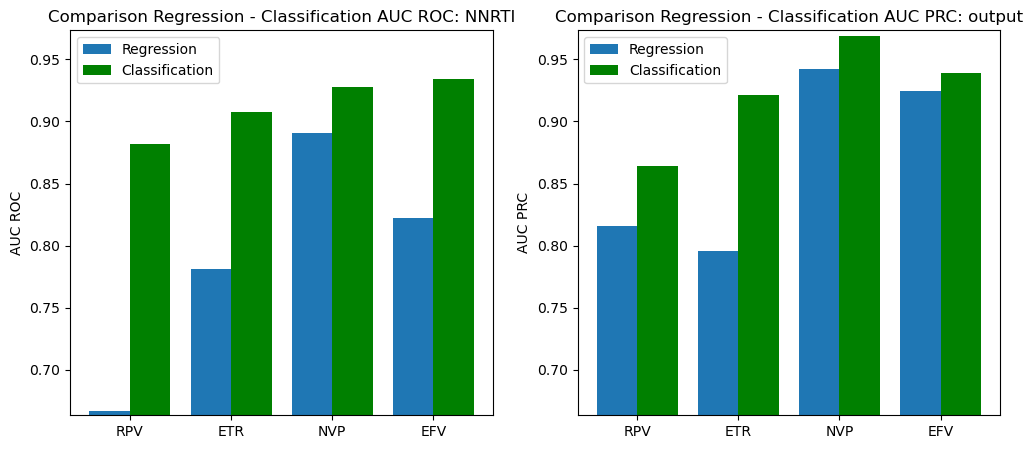

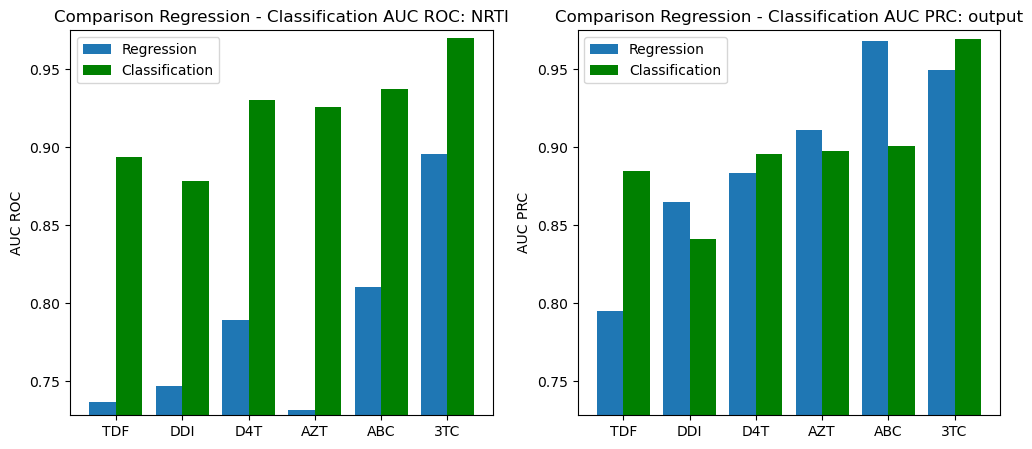

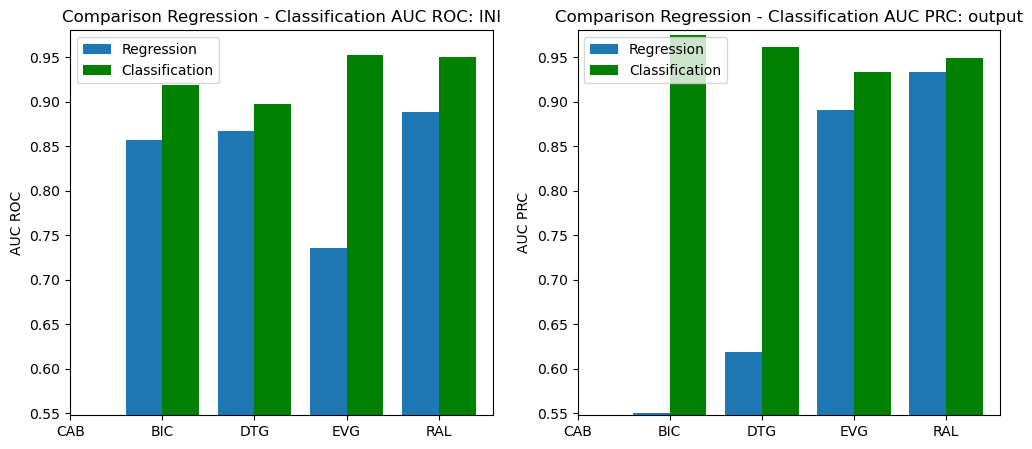

In [9]:


for filepath_re, filepath_st in zip(filepath_list, filepath_list_st):
    target_re = pd.read_csv(filepath_re)
    target_st = pd.read_csv(filepath_st)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    #fig.suptitle('Horizontally stacked subplots')

    w, x = 0.4, np.arange(len(target_re["Drug"]))

    axs[0].bar(x - w/2, target_re["AUC ROC MC"], width=w, label='Regression')
    axs[0].bar(x + w/2, target_st["AUC ROC"], width=w, color="g", label='Classification')

    axs[0].set_xticks(x)
    axs[0].set_xticklabels(target_re["Drug"])
    axs[0].set_ylabel('AUC ROC')
    axs[0].set_ylim(min(target_re['AUC ROC MC'].min(), target_st['AUC ROC'].min(), target_re['AUC PRC BI'].min(), target_st['AUC PRC'].min())* 0.995, min(1.0, max(target_re['AUC ROC MC'].max(), target_st['AUC ROC'].max(), target_re['AUC PRC BI'].max(), target_st['AUC PRC'].max())  * 1.005))
    axs[0].set_title('Comparison Regression - Classification AUC ROC: ' + filepath_re.split("/")[-1].split("_")[0])
    axs[0].legend()


    axs[1].bar(x - w/2, target_re["AUC PRC BI"], width=w, label='Regression')
    axs[1].bar(x + w/2, target_st["AUC PRC"], width=w, color="g", label='Classification')

    axs[1].set_xticks(x)
    axs[1].set_xticklabels(target_re["Drug"])
    axs[1].set_ylabel('AUC PRC')
    axs[1].set_ylim(min(target_re['AUC ROC MC'].min(), target_st['AUC ROC'].min(), target_re['AUC PRC BI'].min(), target_st['AUC PRC'].min())* 0.995, min(1.0, max(target_re['AUC ROC MC'].max(), target_st['AUC ROC'].max(), target_re['AUC PRC BI'].max(), target_st['AUC PRC'].max())  * 1.005))
    axs[1].set_title('Comparison Regression - Classification AUC PRC: ' + filepath_re.split("/")[1].split("_")[0])
    axs[1].legend()


    plt.savefig("../figures/" + filepath_re.split("/")[-1].split("_")[0] + "_Regression_Classification_Comparison.png")


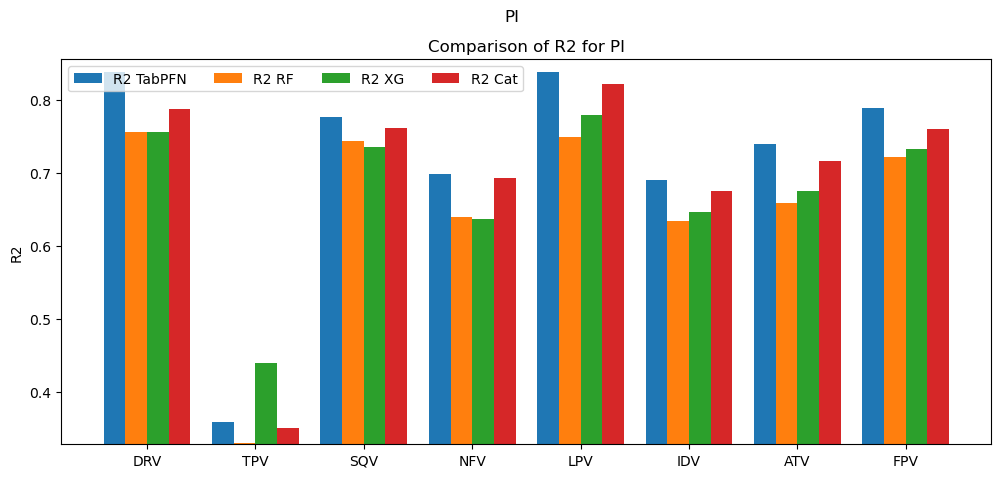

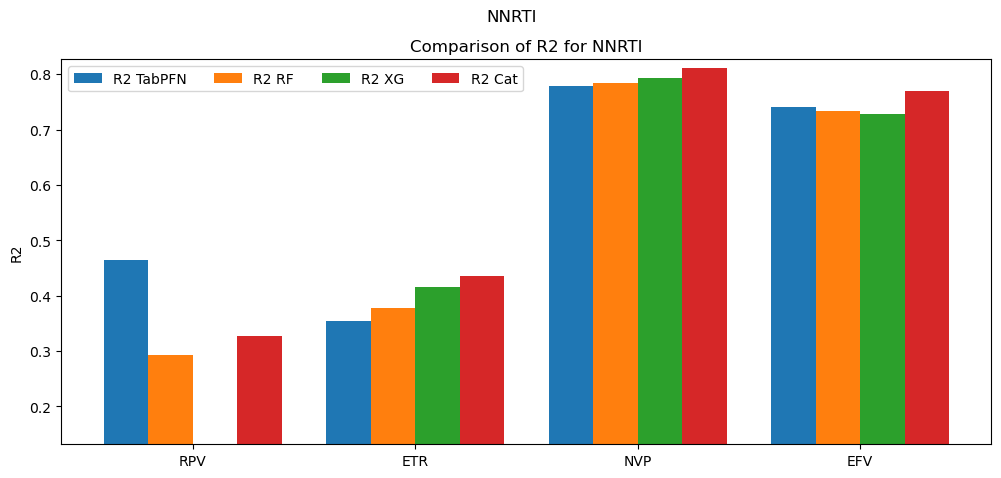

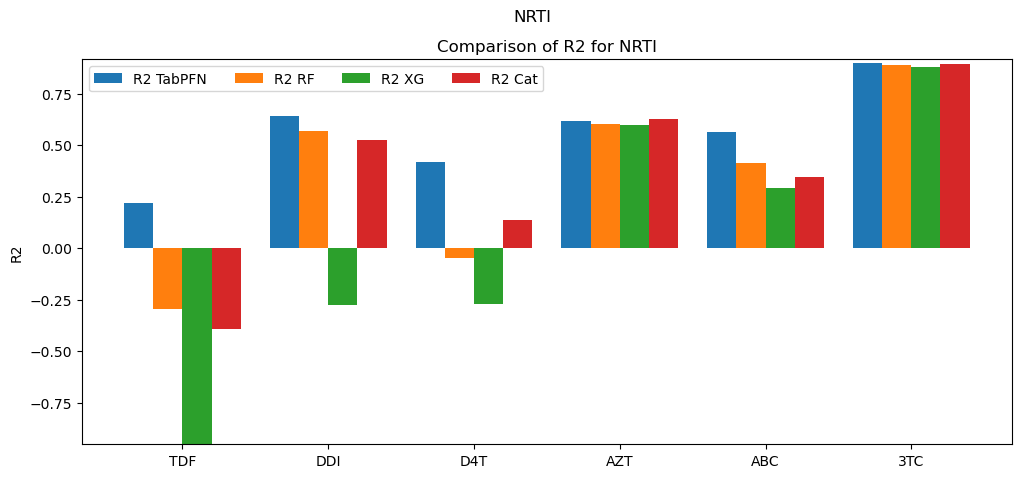

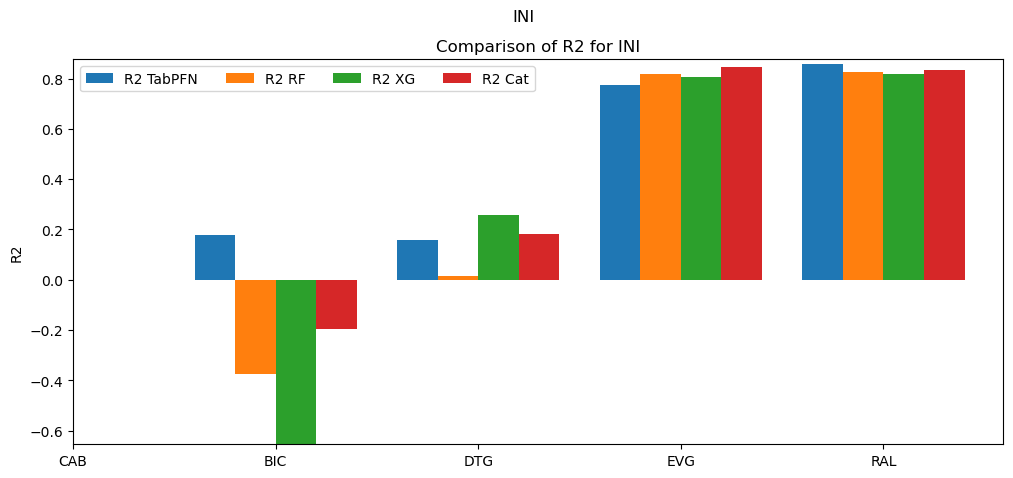

In [10]:
#Grouped bar charts, taken and modified from https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html

width = 0.2  # the width of the bars
multiplier = 0

for filepath in filepath_list:
    df1 = pd.read_csv(filepath)

    target = df1.copy().filter(["R2 TabPFN","R2 RF","R2 XG", "R2 Cat"])

    #target = np.round(target, decimals=3)
    fig, ax = plt.subplots(1, figsize=(12, 5))

    fig.suptitle(filepath.split("/")[-1].split("_")[0])

    x = np.arange(len(target))
    multiplier = 0

    min_r2 = np.min(target)
    max_r2 = np.max(target)

    for attribute, measurement in target.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        #ax.bar_label(rects, padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('R2')
    ax.set_title('Comparison of R2 for ' + filepath.split("/")[-1].split("_")[0])
    ax.set_xticks(x + width * (multiplier - 1) / 2)
    ax.set_xticklabels(df1.Drug)
    ax.legend(loc='upper left', ncols=4)
    ax.set_ylim(min_r2 * 0.995, min(1.0, max_r2 * 1.02))



    plt.savefig("../figures/" + filepath.split("/")[-1].split("_")[0] + "_Regression_comp.png")
